## Feature playground

In [ ]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

sys.path.append('../Extractor') 
sys.path.append('..')

from track import Track

# Set up plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Processed Data
Load the pickle files generated by the extractor. Each pickle contains a `Track` object with pre-computed features and annotations.

In [5]:
data_dir = Path("../../data/processed")
pkl_files = list(data_dir.glob("*.pkl"))

print(f"Found {len(pkl_files)} processed tracks in {data_dir}")

tracks = []
for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            track = pickle.load(f)
            # Ensure we only use tracks that actually have data
            if track.num_bars > 0:
                tracks.append(track)
    except Exception as e:
        print(f"Error loading {pkl_path.name}: {e}")

print(f"Successfully loaded {len(tracks)} tracks")

Found 65 processed tracks in ../../data/processed
Successfully loaded 65 tracks


## 2. Feature Extraction & DataFrame Creation
We transform the list of `Track` objects into a giant "Bar-Wise" DataFrame. 
**1 Row = 1 Bar**.

We extract:
1.  **Raw Features**: The values directly from the extractor (Energy, Vocal Prob, etc.)
2.  **Labels**: Mapping `cue_in` and `cue_out` timestamps to specific bar indices.

In [7]:
def create_base_dataframe(track_list):
    bar_data = []

    for track in track_list:
        num_bars = track.num_bars
        
        # --- Label Mapping ---
        # Convert timestamp cues to bar indices
        cue_in_indices = set()
        cue_out_indices = set()
        
        if hasattr(track, 'cue_in') and len(track.cue_in) > 0:
            # np.searchsorted finds the insertion point (which bar contains this time)
            idxs = np.searchsorted(track.bars, track.cue_in)
            idxs = np.clip(idxs, 0, num_bars - 1)
            cue_in_indices.update(idxs)
            
        if hasattr(track, 'cue_out') and len(track.cue_out) > 0:
            idxs = np.searchsorted(track.bars, track.cue_out)
            idxs = np.clip(idxs, 0, num_bars - 1)
            cue_out_indices.update(idxs)

        # --- Feature Extraction per Bar ---
        for i in range(num_bars):
            row = {
                'track_id': track.track_id,
                'bar_index': i,
                
                # Labels
                'is_cue_in': 1 if i in cue_in_indices else 0,
                'is_cue_out': 1 if i in cue_out_indices else 0,
                
                # Basic Features (Safe access in case some are None)
                'energy': track.energy_per_bar[i] if track.energy_per_bar is not None else 0,
                'bass': track.low_band_energy[i] if track.low_band_energy is not None else 0,
                'highs': track.high_band_energy[i] if track.high_band_energy is not None else 0,
                'rms': track.rms_energy[i] if track.rms_energy is not None else 0,
                'vocal_prob': track.vocal_activity_confidence[i] if track.vocal_activity_confidence is not None else 0,
                'timbre_bright': track.spectral_centroid[i] if track.spectral_centroid is not None else 0,
                'flatness': track.spectral_flatness[i] if track.spectral_flatness is not None else 0,
                'beat_strength': track.beat_strength[i] if track.beat_strength is not None else 0,
                
                # Context info
                'phrase_pos': track.phrase_position[i] if track.phrase_position is not None else (i % 16)
            }
            bar_data.append(row)
            
    return pd.DataFrame(bar_data)

if len(tracks) > 0:
    df = create_base_dataframe(tracks)
    print(f"Created Base DataFrame with {len(df)} bars")
    display(df.head())
else:
    print("No data to process")

Created Base DataFrame with 7248 bars


,track_id,bar_index,is_cue_in,is_cue_out,energy,bass,highs,rms,vocal_prob,timbre_bright,flatness,beat_strength,phrase_pos
0,Da Hype (Junior Jack Original Club Mix),0,0,0,45121.871094,42412.902344,1546.932983,0.240165,0.076276,5753.257465,0.000804,1.635383,0
1,Da Hype (Junior Jack Original Club Mix),1,1,0,44636.796875,41900.187500,1519.819580,0.238218,0.077184,5766.242738,0.000902,1.586264,1
2,Da Hype (Junior Jack Original Club Mix),2,0,0,44574.789062,41953.476562,1507.728516,0.237786,0.081009,5773.764168,0.000999,1.593891,2
3,Da Hype (Junior Jack Original Club Mix),3,0,0,44615.675781,41870.437500,1517.752686,0.237950,0.084492,5768.708592,0.000945,1.596661,3
4,Da Hype (Junior Jack Original Club Mix),4,0,0,44965.046875,42216.855469,1521.914307,0.239831,0.083873,5743.727198,0.000762,1.625157,4


## 3. Feature Engineering
This is where we implement the "DJ Logic". We calculate:
1.  **Context (Rolling)**: "What is the average energy of the last 16 bars?"
2.  **Change (Delta)**: "Did the bass just drop out?"
3.  **Phrasing**: "Are we at the start of a 32-bar phrase?"

In [8]:
def engineer_features(df_in):
    # Work on a copy to avoid SettingWithCopy warnings
    df = df_in.copy()
    
    print("Engineering features...")
    
    # We must group by track_id so rolling windows don't bleed between tracks
    grouped = df.groupby('track_id')
    
    # --- 1. CONTEXT (Rolling Windows) ---
    # "Recent History" features (Past 8-16 bars)
    df['energy_avg_8'] = grouped['energy'].transform(lambda x: x.rolling(window=8, min_periods=1).mean())
    df['bass_avg_16'] = grouped['bass'].transform(lambda x: x.rolling(window=16, min_periods=1).mean())
    df['vocal_avg_8'] = grouped['vocal_prob'].transform(lambda x: x.rolling(window=8, min_periods=1).mean())
    
    # "Future Lookahead" features (Next 8-16 bars) - Using shift(-N)
    # A DJ mixes out knowing a breakdown is coming.
    df['future_energy_8'] = grouped['energy'].shift(-8)
    df['future_bass_8'] = grouped['bass'].shift(-8)
    
    # --- 2. CHANGE DETECTION (Deltas) ---
    # Did the energy change drastically from previous bar?
    df['energy_delta'] = grouped['energy'].diff()
    df['bass_delta'] = grouped['bass'].diff()
    
    # Did we just enter/exit a vocal section?
    df['vocal_delta'] = grouped['vocal_prob'].diff()
    
    # --- 3. PHRASING / GRID ---
    # DJs count in 4s, 8s, 16s, 32s.
    # Convert absolute bar index to modulo grid
    df['bar_mod_32'] = df['bar_index'] % 32
    df['bar_mod_16'] = df['bar_index'] % 16
    
    return df

if len(tracks) > 0:
    df_engineered = engineer_features(df)
    
    # Clean up any NaNs created by shifting/diffing
    df_engineered.fillna(0, inplace=True)
    
    print(f"Feature Engineering Complete. New columns: {len(df_engineered.columns)}")
    display(df_engineered.iloc[30:35][['track_id', 'bar_index', 'energy', 'energy_avg_8', 'energy_delta']])

Engineering features...
Feature Engineering Complete. New columns: 23


,track_id,bar_index,energy,energy_avg_8,energy_delta
30,Da Hype (Junior Jack Original Club Mix),30,66593.460938,56438.416962,1926.718750
31,Da Hype (Junior Jack Original Club Mix),31,67895.500000,64468.830078,1302.039062
32,Da Hype (Junior Jack Original Club Mix),32,4329.083008,57087.486938,-63566.416992
33,Da Hype (Junior Jack Original Club Mix),33,1478.812622,49391.221329,-2850.270386
34,Da Hype (Junior Jack Original Club Mix),34,566.737549,41615.488815,-912.075073


## 4. Visualizing "The Mix Point Signature"
This is the most powerful tool for investigation. 
We align all tracks at their **Cue Out** point and plot the average trajectory of features.
This reveals the "Pattern" of a mix point (e.g., "Bass usually drops 8 bars before the cue").

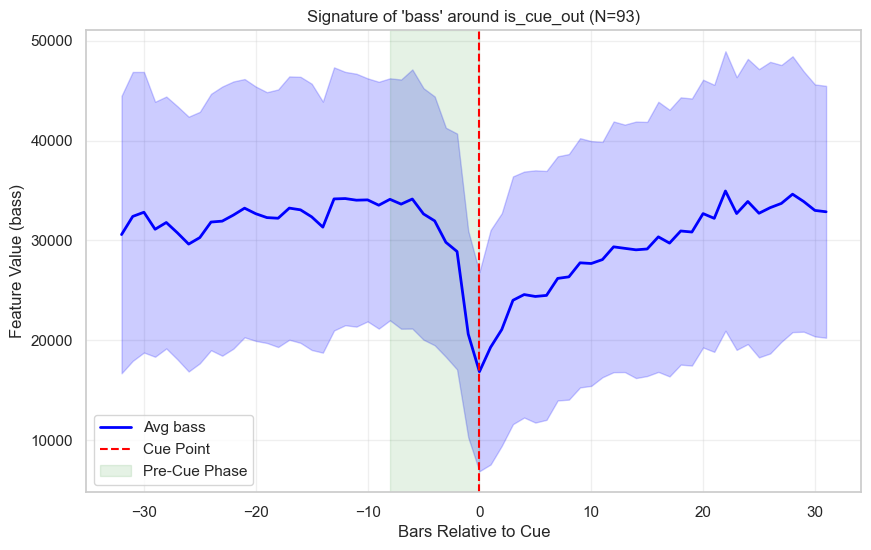

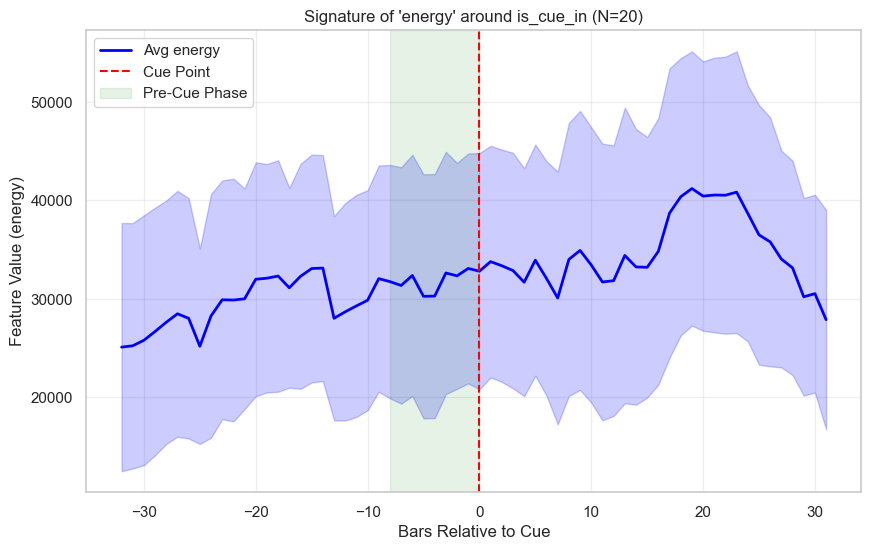

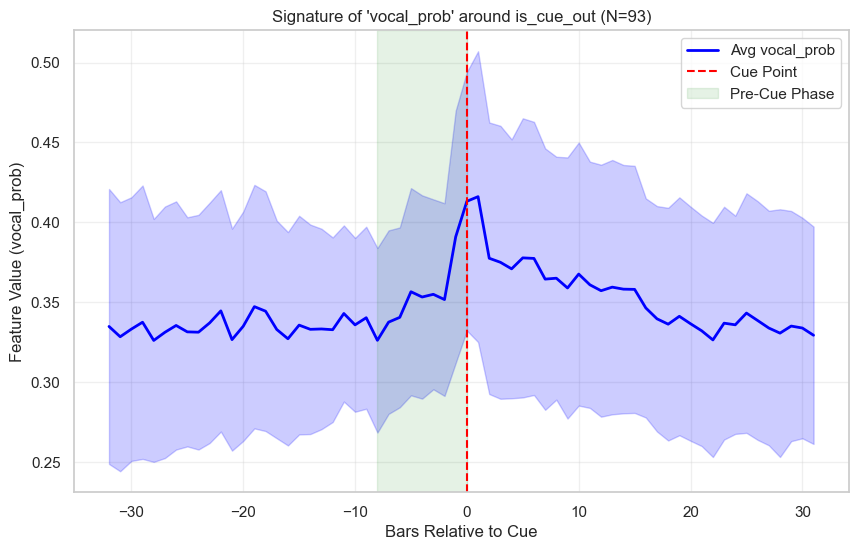

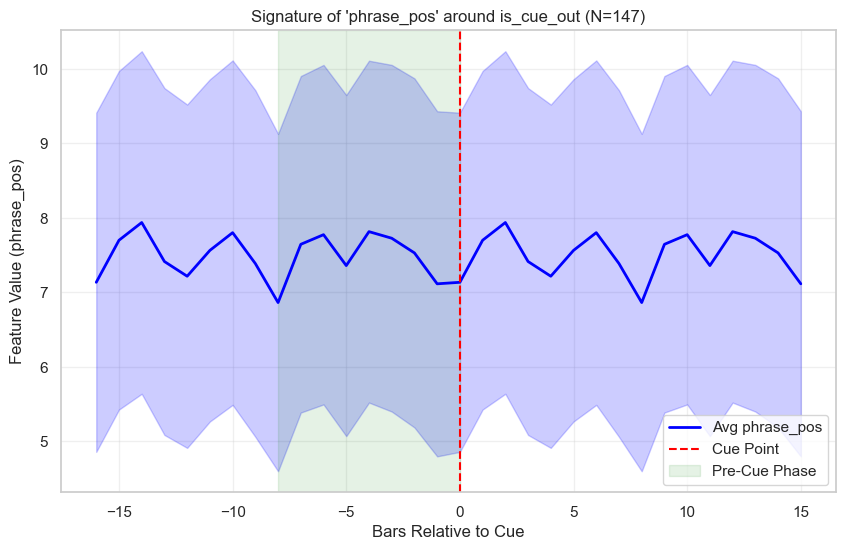

In [9]:
def plot_event_trajectory(df, event_col='is_cue_out', feature='energy', window=32):
    """
    Extracts a window around every 'event' (cue point) and plots the average curve.
    """
    # Find all indices where event occurs
    event_indices = df.index[df[event_col] == 1].tolist()
    
    windows = []
    
    for idx in event_indices:
        # Check if we have enough padding before/after within the SAME track
        start_idx = idx - window
        end_idx = idx + window
        
        # Valid bounds check
        if start_idx < 0 or end_idx >= len(df):
            continue
            
        # Ensure it's the same track ID for the whole window
        track_at_start = df.iloc[start_idx]['track_id']
        track_at_end = df.iloc[end_idx]['track_id']
        
        if track_at_start == track_at_end:
            # Extract the slice
            series = df.iloc[start_idx:end_idx][feature].values
            windows.append(series)
            
    if not windows:
        print(f"No valid windows found for event {event_col}")
        return

    # Aggregate
    data_matrix = np.array(windows)
    mean_curve = np.mean(data_matrix, axis=0)
    std_curve = np.std(data_matrix, axis=0) / 2  # Scaled down std for clearer plot
    
    # X-Axis (Relative Bars)
    x = np.arange(-window, window)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(x, mean_curve, label=f'Avg {feature}', color='blue', linewidth=2)
    plt.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2, color='blue')
    
    # Mark the event
    plt.axvline(0, color='red', linestyle='--', label='Cue Point')
    plt.axvspan(-8, 0, alpha=0.1, color='green', label='Pre-Cue Phase')
    
    plt.title(f"Signature of '{feature}' around {event_col} (N={len(windows)})")
    plt.xlabel("Bars Relative to Cue")
    plt.ylabel(f"Feature Value ({feature})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- PLAY WITH THESE PLOTS ---
# 1. Does the Bass drop before a Cue Out?
plot_event_trajectory(df_engineered, 'is_cue_out', 'bass', window=32)

# 2. Are Cue Ins usually at high energy or low energy?
plot_event_trajectory(df_engineered, 'is_cue_in', 'energy', window=32)

# 3. Do vocals stop before a Cue Out?
plot_event_trajectory(df_engineered, 'is_cue_out', 'vocal_prob', window=32)

# 4. Check 'Phrase Position' - Is it usually 0 (start of phrase) at Cue Out?
plot_event_trajectory(df_engineered, 'is_cue_out', 'phrase_pos', window=16)

## 5. Feature Importance (Boxplots)
Comparison of distribution: Bars containing Cue Points vs Normal Bars.
This tells you which features discriminate well.

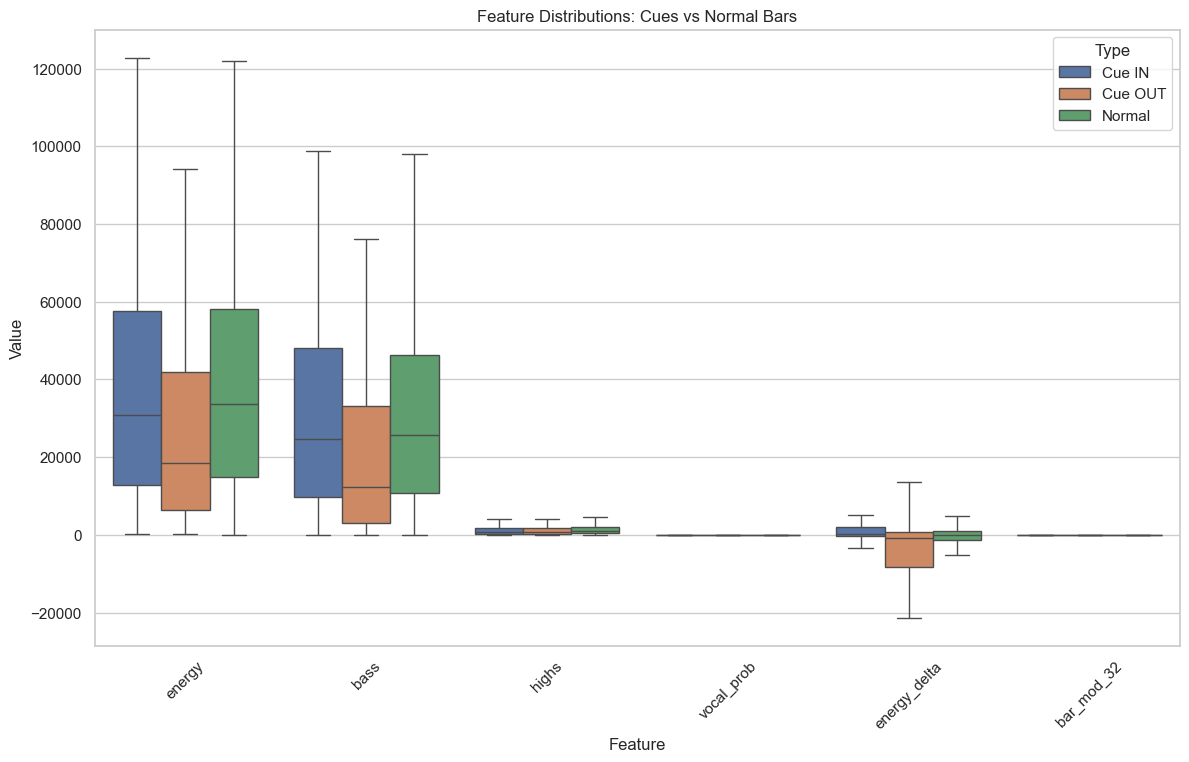

In [10]:
def plot_comparative_boxplots(df):
    features_to_check = ['energy', 'bass', 'highs', 'vocal_prob', 'energy_delta', 'bar_mod_32']
    
    # Create a wrapper column for easy seaborn plotting
    # We prioritize Cue Out, then Cue In, then Normal
    def classify_bar(row):
        if row['is_cue_out'] == 1: return 'Cue OUT'
        if row['is_cue_in'] == 1: return 'Cue IN'
        return 'Normal'
    
    # Sample 'Normal' bars to not overwhelm the plot (class imbalance)
    # We take all Cues, and a random sample of Normal bars
    df_cues = df[(df['is_cue_in'] == 1) | (df['is_cue_out'] == 1)].copy()
    df_normal = df[(df['is_cue_in'] == 0) & (df['is_cue_out'] == 0)].sample(n=len(df_cues)*3, random_state=42).copy()
    
    df_mini = pd.concat([df_cues, df_normal])
    df_mini['Type'] = df_mini.apply(classify_bar, axis=1)
    
    # Melt for Seaborn
    df_melt = df_mini.melt(
        id_vars=['Type'], 
        value_vars=features_to_check, 
        var_name='Feature', 
        value_name='Value'
    )
    
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=df_melt, x='Feature', y='Value', hue='Type', showfliers=False)
    plt.title("Feature Distributions: Cues vs Normal Bars")
    plt.xticks(rotation=45)
    plt.show()

plot_comparative_boxplots(df_engineered)

## 6. Correlation Analysis
Check if we created redundant features. High correlation means we can drop one.

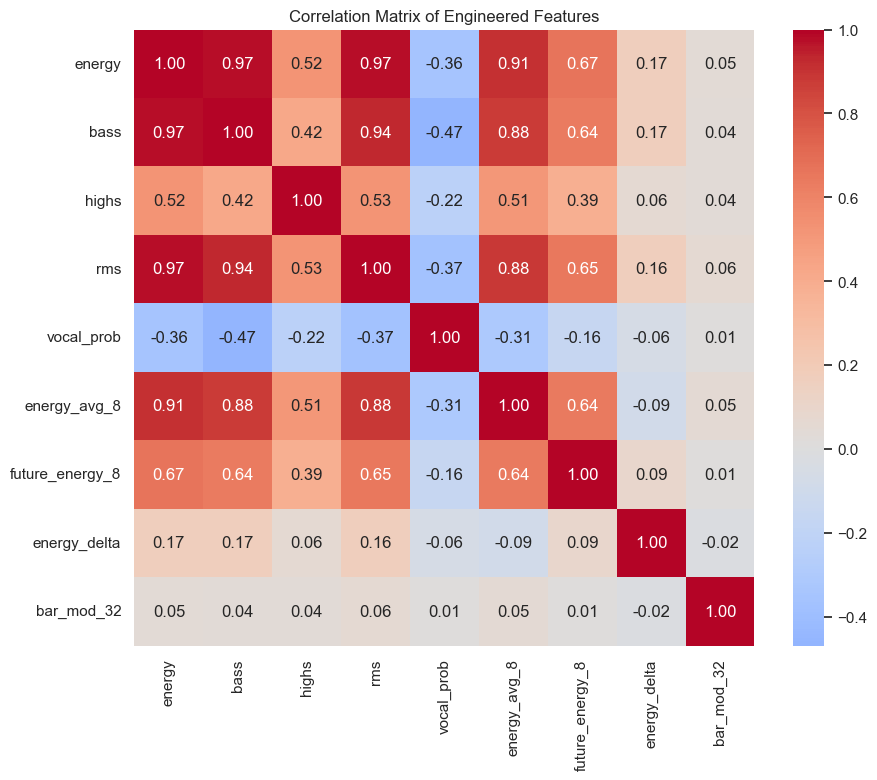

In [11]:
cols = [
    'energy', 'bass', 'highs', 'rms', 'vocal_prob', 
    'energy_avg_8', 'future_energy_8', 'energy_delta', 
    'bar_mod_32'
]

plt.figure(figsize=(10, 8))
corr = df_engineered[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Matrix of Engineered Features")
plt.show()